In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
import matplotlib.patches as patches
import matplotlib as mpl
from mplsoccer import Pitch, VerticalPitch, FontManager, Sbopen, add_image
from matplotlib.font_manager import FontProperties
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as path_effects
from highlight_text import ax_text, fig_text
from PIL import Image
from mplsoccer import add_image
from urllib.request import urlopen
import os


# Print the modified DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

green = '#69f900'
red = '#ff4b44'
blue = '#00a0de'
violet = '#a369ff'
bg_color= '#f5f5f5'
line_color= '#000000'
col1 = '#ff4b44'
col2 = '#00a0de'

# # UCL
# col1 = '#f659fd'
# col2 = '#33efff'
# bg_color = '#060F38'
# line_color = '#ffffff'
# green = '#69f900'
# red = '#ff4b44'

In [2]:
df = pd.read_csv(r"D:\FData\LaLiga_2024_25\laliga_till_gw38.csv")

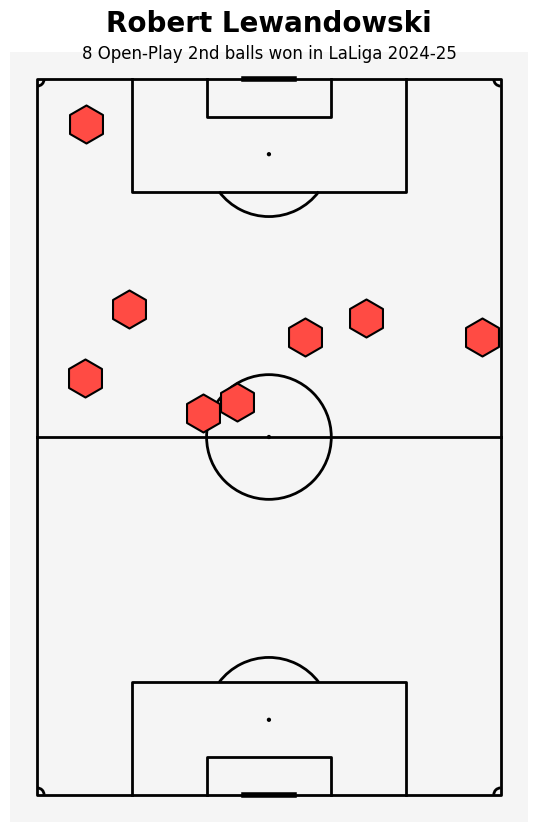

In [25]:
def second_ball(ax, team_name, pname, col):
    # Data Pre-processing
    # adding necessary columns
    dfsb = df.copy()
    dfsb = dfsb[dfsb['type']!='Carry'].reset_index(drop=True)
    dfsb['SetPieceTaken'] = dfsb['qualifiers'].astype(str).str.contains('Freekick|Corner|ThrowIn').astype(int)
    dfsb['Longball'] = dfsb['qualifiers'].astype(str).str.contains('Longball').astype(int)
    dfsb['HeadPass'] = ((dfsb['type'] == 'Pass') & dfsb['qualifiers'].astype(str).str.contains('HeadPass')).astype(int)
    dfsb['shirtNo'] = dfsb['shirtNo'].fillna(0)

    # 2nd Ball Logics
    dfsb['SecondBall1'] = np.where((dfsb['isTouch'] == True) & (dfsb['SetPieceTaken'] == 0) &
                           (((dfsb['type'] != 'BallRecovery') & (dfsb['outcomeType'] == 'Successful')) | 
                            ((dfsb['type'] == 'BallRecovery') & (dfsb['outcomeType'].shift(-1) == 'Successful') & (dfsb['teamName'].shift(-1) == dfsb['teamName']))) &

                            ((dfsb['Longball'].shift(2) == True) & (dfsb['teamName'].shift(2) == dfsb['teamName']) & 
                             (dfsb['outcomeType'].shift(2) == 'Unsuccessful') & 
                             (dfsb['SetPieceTaken'].shift(2) == 0) & (dfsb['SetPieceTaken'].shift(3) == 0) & (dfsb['SetPieceTaken'].shift(4) == 0) &
                             (dfsb['endX'].shift(2) < 105) & (dfsb['endY'].shift(2) < 68)) &
                             
                           (((dfsb['type'].shift(1) == 'Pass') | (dfsb['type'].shift(1) == 'Clearance')  |
                             (dfsb['type'].shift(1) == 'Interception')) & (dfsb['Longball'].shift(1) != True) &
                             (dfsb['teamName'].shift(1) != dfsb['teamName']) & (dfsb['SetPieceTaken'].shift(1) == 0) &
                             (dfsb['position'].shift(1) != 'GK')),1,0)
    
    dfsb['SecondBall2'] = np.where((dfsb['isTouch'] == True) & (dfsb['SetPieceTaken'] == 0) & (dfsb['type'] != 'BallTouch') &
                           (((dfsb['type'] != 'BallRecovery') & (dfsb['outcomeType'] == 'Successful')) | 
                            ((dfsb['type'] == 'BallRecovery') & (dfsb['outcomeType'].shift(-1) == 'Successful') & (dfsb['teamName'].shift(-1) == dfsb['teamName']))) &

                            ((dfsb['Longball'].shift(4) == True) & (dfsb['teamName'].shift(4) == dfsb['teamName']) & 
                             (dfsb['outcomeType'].shift(4) == 'Unsuccessful') & 
                             (dfsb['SetPieceTaken'].shift(4) == 0) & (dfsb['SetPieceTaken'].shift(5) == 0) & (dfsb['SetPieceTaken'].shift(6) == 0) &
                             (dfsb['endX'].shift(4) < 105) & (dfsb['endY'].shift(4) < 68)) &
                             
                            ((dfsb['type'].shift(3) == 'Aerial') & (dfsb['outcomeType'].shift(3) == 'Successful') &
                             (dfsb['teamName'].shift(3) != dfsb['teamName'])) & 
                             
                            ((dfsb['type'].shift(2) == 'Aerial') & (dfsb['outcomeType'].shift(2) == 'Unsuccessful') &
                             (dfsb['teamName'].shift(2) == dfsb['teamName'])) &                            
                             
                           (((dfsb['type'].shift(1) == 'Pass') | (dfsb['type'].shift(1) == 'Clearance') |
                            (dfsb['type'].shift(1) == 'Interception')) & (dfsb['Longball'].shift(1) != True) &
                             (dfsb['teamName'].shift(1) != dfsb['teamName']) & (dfsb['SetPieceTaken'].shift(1) == 0) &
                             (dfsb['position'].shift(1) != 'GK')),1,0)
    
    dfsb['SecondBall3'] = np.where((dfsb['isTouch'] == True) & (dfsb['SetPieceTaken'] == 0) & 
                           (((dfsb['type'] != 'BallRecovery') & (dfsb['outcomeType'] == 'Successful')) | 
                            ((dfsb['type'] == 'BallRecovery') & (dfsb['outcomeType'].shift(-1) == 'Successful') & (dfsb['teamName'].shift(-1) == dfsb['teamName']))) &
                             
                            ((dfsb['Longball'].shift(3) == True) & (dfsb['teamName'].shift(3) == dfsb['teamName']) & 
                             (dfsb['outcomeType'].shift(3) == 'Unsuccessful') & 
                             (dfsb['SetPieceTaken'].shift(3) == 0) & (dfsb['SetPieceTaken'].shift(4) == 0) & (dfsb['SetPieceTaken'].shift(5) == 0) &
                             (dfsb['endX'].shift(3) < 105) & (dfsb['endY'].shift(3) < 68)) &
                             
                            ((dfsb['type'].shift(2) == 'BallRecovery') & (dfsb['teamName'].shift(2) != dfsb['teamName'])) &                           
                             
                           (((dfsb['type'].shift(1) == 'Pass') | (dfsb['type'].shift(1) == 'Clearance') |
                            (dfsb['type'].shift(1) == 'Interception')) & (dfsb['Longball'].shift(1) != True) &
                             (dfsb['teamName'].shift(1) != dfsb['teamName']) & (dfsb['SetPieceTaken'].shift(1) == 0) &
                             (dfsb['position'].shift(1) != 'GK')),1,0)

    dfsb['SecondBall4'] = np.where((dfsb['isTouch'] == True) & (dfsb['SetPieceTaken'] == 0) &
                           (((dfsb['type'] != 'BallRecovery') & (dfsb['outcomeType'] == 'Successful')) | 
                            ((dfsb['type'] == 'BallRecovery') & (dfsb['outcomeType'].shift(-1) == 'Successful') & (dfsb['teamName'].shift(-1) == dfsb['teamName']))) &
                             
                            ((dfsb['Longball'].shift(2) == True) & (dfsb['teamName'].shift(2) == dfsb['teamName']) & 
                             (dfsb['outcomeType'].shift(2) == 'Successful') & 
                             (dfsb['SetPieceTaken'].shift(2) == 0) & (dfsb['SetPieceTaken'].shift(3) == 0) & (dfsb['SetPieceTaken'].shift(4) == 0) &
                             (dfsb['endX'].shift(2) < 105) & (dfsb['endY'].shift(2) < 68)) &
                              
                            ((dfsb['HeadPass'].shift(1) == 1) & (dfsb['Longball'].shift(1) != True) &
                             (dfsb['teamName'].shift(1) == dfsb['teamName']) & (dfsb['SetPieceTaken'].shift(1) == 0) &
                             (dfsb['position'].shift(1) != 'GK')),1,0) 

    dfsb['SecondBall5'] = np.where((dfsb['isTouch'] == True) & (dfsb['SetPieceTaken'] == 0) & 
                             (dfsb['type'] != 'BallTouch') &
                           (((dfsb['type'] != 'BallRecovery') & (dfsb['outcomeType'] == 'Successful')) | 
                            ((dfsb['type'] == 'BallRecovery') & (dfsb['outcomeType'].shift(-1) == 'Successful') & (dfsb['teamName'].shift(-1) == dfsb['teamName']))) &
                             
                            ((dfsb['Longball'].shift(4) == True) & (dfsb['teamName'].shift(4) != dfsb['teamName']) & 
                             (dfsb['outcomeType'].shift(4) == 'Successful') & 
                             (dfsb['SetPieceTaken'].shift(4) == 0) & (dfsb['SetPieceTaken'].shift(5) == 0) & (dfsb['SetPieceTaken'].shift(6) == 0) &
                             (dfsb['endX'].shift(4) < 105) & (dfsb['endY'].shift(4) < 68)) &
                             
                            ((dfsb['type'].shift(3) == 'Aerial') & (dfsb['outcomeType'].shift(3) == 'Successful') &
                             (dfsb['teamName'].shift(3) != dfsb['teamName'])) & 
                             
                            ((dfsb['type'].shift(2) == 'Aerial') & (dfsb['outcomeType'].shift(2) == 'Unsuccessful') &
                             (dfsb['teamName'].shift(2) == dfsb['teamName'])) &                            
                              
                           (((dfsb['type'].shift(1) == 'Pass') & (dfsb['outcomeType'].shift(1) == 'Unsuccessful')) &
                             (dfsb['Longball'].shift(1) != True) & (dfsb['teamName'].shift(1) != dfsb['teamName']) & 
                             (dfsb['SetPieceTaken'].shift(1) == 0) & (dfsb['position'].shift(1) != 'GK')),1,0)

    dfsb['SecondBall6'] = np.where((dfsb['isTouch'] == True) & (dfsb['SetPieceTaken'] == 0) & 
                             (dfsb['type'] != 'BallTouch') &
                           (((dfsb['type'] != 'BallRecovery') & (dfsb['outcomeType'] == 'Successful')) | 
                            ((dfsb['type'] == 'BallRecovery') & (dfsb['outcomeType'].shift(-1) == 'Successful') & (dfsb['teamName'].shift(-1) == dfsb['teamName']))) &
                             
                            ((dfsb['Longball'].shift(3) == True) & (dfsb['teamName'].shift(3) != dfsb['teamName']) & 
                             (dfsb['outcomeType'].shift(3) == 'Successful') & 
                             (dfsb['SetPieceTaken'].shift(3) == 0) & (dfsb['SetPieceTaken'].shift(4) == 0) & (dfsb['SetPieceTaken'].shift(5) == 0) &
                             (dfsb['endX'].shift(3) < 105) & (dfsb['endY'].shift(3) < 68)) &
                             
                            ((dfsb['type'].shift(2) == 'Aerial') & (dfsb['outcomeType'].shift(2) == 'Successful') &
                             (dfsb['teamName'].shift(2) != dfsb['teamName'])) & 
                             
                            ((dfsb['type'].shift(1) == 'Aerial') & (dfsb['outcomeType'].shift(1) == 'Unsuccessful') &
                             (dfsb['teamName'].shift(1) == dfsb['teamName'])),1,0)

    dfsb['SecondBall7'] = np.where((dfsb['isTouch'] == True) & (dfsb['SetPieceTaken'] == 0) & 
                           (((dfsb['type'] != 'BallRecovery') & (dfsb['outcomeType'] == 'Successful')) | 
                            ((dfsb['type'] == 'BallRecovery') & (dfsb['outcomeType'].shift(-1) == 'Successful') & (dfsb['teamName'].shift(-1) == dfsb['teamName']))) &
                             
                            ((dfsb['Longball'].shift(2) == True) & (dfsb['teamName'].shift(2) != dfsb['teamName']) & 
                             (dfsb['outcomeType'].shift(2) == 'Unsuccessful') & 
                             (dfsb['SetPieceTaken'].shift(2) == 0) & (dfsb['SetPieceTaken'].shift(3) == 0) & (dfsb['SetPieceTaken'].shift(4) == 0) &
                             (dfsb['endX'].shift(2) < 105) & (dfsb['endY'].shift(2) < 68)) &
                             
                           (((dfsb['type'].shift(1) == 'Pass') | (dfsb['type'].shift(1) == 'Clearance')  |
                             (dfsb['type'].shift(1) == 'Interception')) & (dfsb['Longball'].shift(1) != True) &
                             (dfsb['teamName'].shift(1) == dfsb['teamName']) & (dfsb['SetPieceTaken'].shift(1) == 0) &
                             (dfsb['position'].shift(1) != 'GK')),1,0)

    

    dfsb['SecondBall'] = dfsb['SecondBall1'] + dfsb['SecondBall2'] + dfsb['SecondBall3'] + dfsb['SecondBall4'] + dfsb['SecondBall5'] + dfsb['SecondBall6'] + dfsb['SecondBall7']
    
    
    
    pitch = VerticalPitch(pitch_type='uefa', corner_arcs=True, pitch_color=bg_color, line_color=line_color, line_zorder=1, linewidth=2)
    pitch.draw(ax=ax)

    team_sb = dfsb[(dfsb['teamName']==team_name) & (dfsb['SecondBall'] > 0)]

    pdf = team_sb[team_sb['name']==pname]

    pitch.scatter(pdf.x, pdf.y, s=750, marker='h', color=col, edgecolor=line_color, lw=1.5, ax=ax)
    # Plotting the shirt no. of each player
    # for index, row in pdf.iterrows():
    #     player_initials = int(row["shirtNo"])
    #     pitch.annotate(player_initials, xy=(row.x, row.y), c=bg_color, ha='center', va='center', size=12, zorder=4, ax=ax)

    ax.text(34, 112, pname, fontsize=20, fontweight='bold', ha='center')
    ax.text(34, 108, f'{len(pdf)} Open-Play 2nd balls won in LaLiga 2024-25', fontsize=12, ha='center')

    return team_sb

fig, ax = plt.subplots(figsize=(10,10))
team_sb = second_ball(ax, 'Barcelona', 'Robert Lewandowski', col1)

In [14]:
pdf = team_sb.groupby(['name', 'shirtNo']).size().reset_index(name='Count')
pdf = pdf.sort_values(by='Count', ascending=False)
pdf

,name,shirtNo,Count
12,Inigo Martinez,5.0,16
21,Pedri,8.0,15
16,Marc Casado,17.0,12
13,Jules Kounde,23.0,10
23,Robert Lewandowski,9.0,8
7,Frenkie de Jong,21.0,6
9,Gerard Martin,35.0,6
19,Pau Cubarsi,2.0,5
14,Lamine Yamal,19.0,5
22,Raphinha,11.0,5


In [7]:
def second_ball(team_name, pname):
    # Data Pre-processing
    # adding necessary columns
    dfsb = df.copy()
    dfsb = dfsb[dfsb['type']!='Carry'].reset_index(drop=True)
    dfsb['SetPieceTaken'] = dfsb['qualifiers'].astype(str).str.contains('Freekick|Corner|ThrowIn').astype(int)
    dfsb['Longball'] = dfsb['qualifiers'].astype(str).str.contains('Longball').astype(int)
    dfsb['HeadPass'] = ((dfsb['type'] == 'Pass') & dfsb['qualifiers'].astype(str).str.contains('HeadPass')).astype(int)
    dfsb['shirtNo'] = dfsb['shirtNo'].fillna(0)

    # 2nd Ball Logics
    dfsb['SecondBall1'] = np.where((dfsb['isTouch'] == True) & (dfsb['SetPieceTaken'] == 0) &
                           (((dfsb['type'] != 'BallRecovery') & (dfsb['outcomeType'] == 'Successful')) | 
                            ((dfsb['type'] == 'BallRecovery') & (dfsb['outcomeType'].shift(-1) == 'Successful') & (dfsb['teamName'].shift(-1) == dfsb['teamName']))) &

                            ((dfsb['Longball'].shift(2) == True) & (dfsb['teamName'].shift(2) == dfsb['teamName']) & 
                             (dfsb['outcomeType'].shift(2) == 'Unsuccessful') & 
                             (dfsb['SetPieceTaken'].shift(2) == 0) & (dfsb['SetPieceTaken'].shift(3) == 0) & (dfsb['SetPieceTaken'].shift(4) == 0) &
                             (dfsb['endX'].shift(2) < 105) & (dfsb['endY'].shift(2) < 68)) &
                             
                           (((dfsb['type'].shift(1) == 'Pass') | (dfsb['type'].shift(1) == 'Clearance')  |
                             (dfsb['type'].shift(1) == 'Interception')) & (dfsb['Longball'].shift(1) != True) &
                             (dfsb['teamName'].shift(1) != dfsb['teamName']) & (dfsb['SetPieceTaken'].shift(1) == 0) &
                             (dfsb['position'].shift(1) != 'GK')),1,0)
    
    dfsb['SecondBall2'] = np.where((dfsb['isTouch'] == True) & (dfsb['SetPieceTaken'] == 0) & (dfsb['type'] != 'BallTouch') &
                           (((dfsb['type'] != 'BallRecovery') & (dfsb['outcomeType'] == 'Successful')) | 
                            ((dfsb['type'] == 'BallRecovery') & (dfsb['outcomeType'].shift(-1) == 'Successful') & (dfsb['teamName'].shift(-1) == dfsb['teamName']))) &

                            ((dfsb['Longball'].shift(4) == True) & (dfsb['teamName'].shift(4) == dfsb['teamName']) & 
                             (dfsb['outcomeType'].shift(4) == 'Unsuccessful') & 
                             (dfsb['SetPieceTaken'].shift(4) == 0) & (dfsb['SetPieceTaken'].shift(5) == 0) & (dfsb['SetPieceTaken'].shift(6) == 0) &
                             (dfsb['endX'].shift(4) < 105) & (dfsb['endY'].shift(4) < 68)) &
                             
                            ((dfsb['type'].shift(3) == 'Aerial') & (dfsb['outcomeType'].shift(3) == 'Successful') &
                             (dfsb['teamName'].shift(3) != dfsb['teamName'])) & 
                             
                            ((dfsb['type'].shift(2) == 'Aerial') & (dfsb['outcomeType'].shift(2) == 'Unsuccessful') &
                             (dfsb['teamName'].shift(2) == dfsb['teamName'])) &                            
                             
                           (((dfsb['type'].shift(1) == 'Pass') | (dfsb['type'].shift(1) == 'Clearance') |
                            (dfsb['type'].shift(1) == 'Interception')) & (dfsb['Longball'].shift(1) != True) &
                             (dfsb['teamName'].shift(1) != dfsb['teamName']) & (dfsb['SetPieceTaken'].shift(1) == 0) &
                             (dfsb['position'].shift(1) != 'GK')),1,0)
    
    dfsb['SecondBall3'] = np.where((dfsb['isTouch'] == True) & (dfsb['SetPieceTaken'] == 0) & 
                           (((dfsb['type'] != 'BallRecovery') & (dfsb['outcomeType'] == 'Successful')) | 
                            ((dfsb['type'] == 'BallRecovery') & (dfsb['outcomeType'].shift(-1) == 'Successful') & (dfsb['teamName'].shift(-1) == dfsb['teamName']))) &
                             
                            ((dfsb['Longball'].shift(3) == True) & (dfsb['teamName'].shift(3) == dfsb['teamName']) & 
                             (dfsb['outcomeType'].shift(3) == 'Unsuccessful') & 
                             (dfsb['SetPieceTaken'].shift(3) == 0) & (dfsb['SetPieceTaken'].shift(4) == 0) & (dfsb['SetPieceTaken'].shift(5) == 0) &
                             (dfsb['endX'].shift(3) < 105) & (dfsb['endY'].shift(3) < 68)) &
                             
                            ((dfsb['type'].shift(2) == 'BallRecovery') & (dfsb['teamName'].shift(2) != dfsb['teamName'])) &                           
                             
                           (((dfsb['type'].shift(1) == 'Pass') | (dfsb['type'].shift(1) == 'Clearance') |
                            (dfsb['type'].shift(1) == 'Interception')) & (dfsb['Longball'].shift(1) != True) &
                             (dfsb['teamName'].shift(1) != dfsb['teamName']) & (dfsb['SetPieceTaken'].shift(1) == 0) &
                             (dfsb['position'].shift(1) != 'GK')),1,0)

    dfsb['SecondBall4'] = np.where((dfsb['isTouch'] == True) & (dfsb['SetPieceTaken'] == 0) &
                           (((dfsb['type'] != 'BallRecovery') & (dfsb['outcomeType'] == 'Successful')) | 
                            ((dfsb['type'] == 'BallRecovery') & (dfsb['outcomeType'].shift(-1) == 'Successful') & (dfsb['teamName'].shift(-1) == dfsb['teamName']))) &
                             
                            ((dfsb['Longball'].shift(2) == True) & (dfsb['teamName'].shift(2) == dfsb['teamName']) & 
                             (dfsb['outcomeType'].shift(2) == 'Successful') & 
                             (dfsb['SetPieceTaken'].shift(2) == 0) & (dfsb['SetPieceTaken'].shift(3) == 0) & (dfsb['SetPieceTaken'].shift(4) == 0) &
                             (dfsb['endX'].shift(2) < 105) & (dfsb['endY'].shift(2) < 68)) &
                              
                            ((dfsb['HeadPass'].shift(1) == 1) & (dfsb['Longball'].shift(1) != True) &
                             (dfsb['teamName'].shift(1) == dfsb['teamName']) & (dfsb['SetPieceTaken'].shift(1) == 0) &
                             (dfsb['position'].shift(1) != 'GK')),1,0) 

    dfsb['SecondBall5'] = np.where((dfsb['isTouch'] == True) & (dfsb['SetPieceTaken'] == 0) & 
                             (dfsb['type'] != 'BallTouch') &
                           (((dfsb['type'] != 'BallRecovery') & (dfsb['outcomeType'] == 'Successful')) | 
                            ((dfsb['type'] == 'BallRecovery') & (dfsb['outcomeType'].shift(-1) == 'Successful') & (dfsb['teamName'].shift(-1) == dfsb['teamName']))) &
                             
                            ((dfsb['Longball'].shift(4) == True) & (dfsb['teamName'].shift(4) != dfsb['teamName']) & 
                             (dfsb['outcomeType'].shift(4) == 'Successful') & 
                             (dfsb['SetPieceTaken'].shift(4) == 0) & (dfsb['SetPieceTaken'].shift(5) == 0) & (dfsb['SetPieceTaken'].shift(6) == 0) &
                             (dfsb['endX'].shift(4) < 105) & (dfsb['endY'].shift(4) < 68)) &
                             
                            ((dfsb['type'].shift(3) == 'Aerial') & (dfsb['outcomeType'].shift(3) == 'Successful') &
                             (dfsb['teamName'].shift(3) != dfsb['teamName'])) & 
                             
                            ((dfsb['type'].shift(2) == 'Aerial') & (dfsb['outcomeType'].shift(2) == 'Unsuccessful') &
                             (dfsb['teamName'].shift(2) == dfsb['teamName'])) &                            
                              
                           (((dfsb['type'].shift(1) == 'Pass') & (dfsb['outcomeType'].shift(1) == 'Unsuccessful')) &
                             (dfsb['Longball'].shift(1) != True) & (dfsb['teamName'].shift(1) != dfsb['teamName']) & 
                             (dfsb['SetPieceTaken'].shift(1) == 0) & (dfsb['position'].shift(1) != 'GK')),1,0)

    dfsb['SecondBall6'] = np.where((dfsb['isTouch'] == True) & (dfsb['SetPieceTaken'] == 0) & 
                             (dfsb['type'] != 'BallTouch') &
                           (((dfsb['type'] != 'BallRecovery') & (dfsb['outcomeType'] == 'Successful')) | 
                            ((dfsb['type'] == 'BallRecovery') & (dfsb['outcomeType'].shift(-1) == 'Successful') & (dfsb['teamName'].shift(-1) == dfsb['teamName']))) &
                             
                            ((dfsb['Longball'].shift(3) == True) & (dfsb['teamName'].shift(3) != dfsb['teamName']) & 
                             (dfsb['outcomeType'].shift(3) == 'Successful') & 
                             (dfsb['SetPieceTaken'].shift(3) == 0) & (dfsb['SetPieceTaken'].shift(4) == 0) & (dfsb['SetPieceTaken'].shift(5) == 0) &
                             (dfsb['endX'].shift(3) < 105) & (dfsb['endY'].shift(3) < 68)) &
                             
                            ((dfsb['type'].shift(2) == 'Aerial') & (dfsb['outcomeType'].shift(2) == 'Successful') &
                             (dfsb['teamName'].shift(2) != dfsb['teamName'])) & 
                             
                            ((dfsb['type'].shift(1) == 'Aerial') & (dfsb['outcomeType'].shift(1) == 'Unsuccessful') &
                             (dfsb['teamName'].shift(1) == dfsb['teamName'])),1,0)

    dfsb['SecondBall7'] = np.where((dfsb['isTouch'] == True) & (dfsb['SetPieceTaken'] == 0) & 
                           (((dfsb['type'] != 'BallRecovery') & (dfsb['outcomeType'] == 'Successful')) | 
                            ((dfsb['type'] == 'BallRecovery') & (dfsb['outcomeType'].shift(-1) == 'Successful') & (dfsb['teamName'].shift(-1) == dfsb['teamName']))) &
                             
                            ((dfsb['Longball'].shift(2) == True) & (dfsb['teamName'].shift(2) != dfsb['teamName']) & 
                             (dfsb['outcomeType'].shift(2) == 'Unsuccessful') & 
                             (dfsb['SetPieceTaken'].shift(2) == 0) & (dfsb['SetPieceTaken'].shift(3) == 0) & (dfsb['SetPieceTaken'].shift(4) == 0) &
                             (dfsb['endX'].shift(2) < 105) & (dfsb['endY'].shift(2) < 68)) &
                             
                           (((dfsb['type'].shift(1) == 'Pass') | (dfsb['type'].shift(1) == 'Clearance')  |
                             (dfsb['type'].shift(1) == 'Interception')) & (dfsb['Longball'].shift(1) != True) &
                             (dfsb['teamName'].shift(1) == dfsb['teamName']) & (dfsb['SetPieceTaken'].shift(1) == 0) &
                             (dfsb['position'].shift(1) != 'GK')),1,0)

    

    dfsb['SecondBall'] = dfsb['SecondBall1'] + dfsb['SecondBall2'] + dfsb['SecondBall3'] + dfsb['SecondBall4'] + dfsb['SecondBall5'] + dfsb['SecondBall6'] + dfsb['SecondBall7']
    

    team_sb = dfsb[(dfsb['teamName']==team_name) & (dfsb['SecondBall'] > 0)]

    # pdf = team_sb[team_sb['name']==pname]
    
    return {"Team": team_name, "Count": len(team_sb)}



In [3]:
df.columns.to_list()

['index',
 'eventId',
 'minute',
 'second',
 'teamId',
 'x',
 'y',
 'expandedMinute',
 'period',
 'type',
 'outcomeType',
 'qualifiers',
 'satisfiedEventsTypes',
 'isTouch',
 'playerId',
 'endX',
 'endY',
 'blockedX',
 'blockedY',
 'goalMouthZ',
 'goalMouthY',
 'isShot',
 'relatedEventId',
 'relatedPlayerId',
 'cumulative_mins',
 'x1_bin_xT',
 'y1_bin_xT',
 'x2_bin_xT',
 'y2_bin_xT',
 'start_zone_value_xT',
 'end_zone_value_xT',
 'xT',
 'teamName',
 'oppositionTeamName',
 'shirtNo',
 'name',
 'position',
 'isFirstEleven',
 'prog_pass',
 'prog_carry',
 'pass_or_carry_angle',
 'pass_or_carry_length',
 'shortName',
 'possession_id',
 'possession_team',
 'match_id',
 'home_team_name',
 'away_team_name']